<a href="https://colab.research.google.com/github/camilla-sophia/An-lise-de-h-bitos-estudantis/blob/main/student_performance_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
#importação bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
#importação database do drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
#importação database
df = pd.read_csv('/content/drive/MyDrive/student_performance/StudentHabits.zip')

In [61]:
#mostrar primeiras cinco linhas
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [62]:
#mostrar quantas linhas e colunas tem o dataset
df.shape

(1000, 12)

In [63]:
#mostrar nome de cada coluna, quantos valores não nulos tem nela e
#tipo de dado
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [64]:
#gerar estatísticas básicas (média, mínimo, máximo, desvio padrão)
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [65]:
#verificar linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [66]:
#verificar valores nulos nas colunas
df.isnull().sum()

,0
student_id,0
gender,0
study_time_hours,0
attendance_percent,0
sleep_hours,0
parental_education,102
internet_access,0
extracurricular_activities,0
part_time_job,0
previous_grade,0


In [67]:
#inserção de "Not specified" nas cédulas nulas em parental_education
df['parental_education'] = df['parental_education'].fillna('Not specified')

In [68]:
#verificação tabela atualizada
df.isnull().sum()

,0
student_id,0
gender,0
study_time_hours,0
attendance_percent,0
sleep_hours,0
parental_education,0
internet_access,0
extracurricular_activities,0
part_time_job,0
previous_grade,0


In [69]:
#verificação colunas categóricas (texto)
for coluna in ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'final_grade']:
  print(coluna, ': ', df[coluna].unique())

gender :  ['Male' 'Female']
parental_education :  ['Bachelors' 'High School' 'Not specified' 'Masters' 'PhD']
internet_access :  ['Yes' 'No']
extracurricular_activities :  ['Yes' 'No']
part_time_job :  ['No' 'Yes']
final_grade :  ['A' 'B' 'D' 'C' 'F']


In [70]:
#codificação ordinal para final_grade
#criação do dicionário de notas
mapa_notas = {'F': 1, 'D': 2, 'C': 3, 'B': 4, 'A': 5}
#aplicação da troca, com adição da nova coluna chamada final_grade_num
df['final_grade_num'] = df['final_grade'].map(mapa_notas)

In [71]:
#one-hot encoding para colunas sem ordem
df = pd.get_dummies(df, columns=['gender', 'internet_access', 'extracurricular_activities', 'part_time_job', 'parental_education'])

In [ ]:
#GRÁFICOS

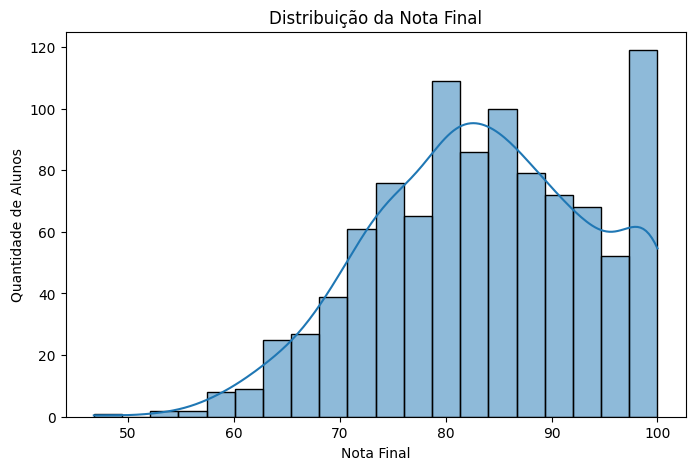

In [72]:
#distribuição da nota final
#tamanho da imagem do gráfico (largura e altura)
plt.figure(figsize=(8,5))
#criação de um histograma (bins = faixas, kde = linha mostrando tendência de distribuição em cima):
sns.histplot(df['final_exam_score'], bins=20, kde=True)
#textos do gráfico:
plt.title('Distribuição da Nota Final')
plt.xlabel('Nota Final')
plt.ylabel('Quantidade de Alunos')
#exibir gráfico:
plt.show()

In [ ]:
#é possível notar que a maioria dos alunos tem alta dominação do conteúdo, devido à grande média no topo da escala

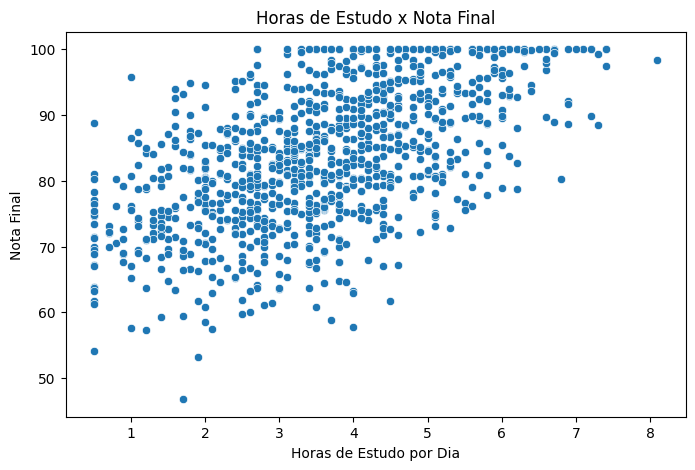

In [73]:
#horas de estudo x nota final
plt.figure(figsize = (8,5))
sns.scatterplot(data=df, x='study_time_hours', y='final_exam_score')
plt.title('Horas de Estudo x Nota Final')
plt.xlabel('Horas de Estudo por Dia')
plt.ylabel('Nota Final')
plt.show()

In [ ]:
#tendencia de quanto mais horas de estudo, maior a nota final, aumento em diagonal
#mesmo com poucas horas de estudo, a variação de notas vai de 47 até quase 90, então pode depender de outros fatores
#a partir de 3-4 horas de estudo, a maioria dos alunos está entre 80 a 100

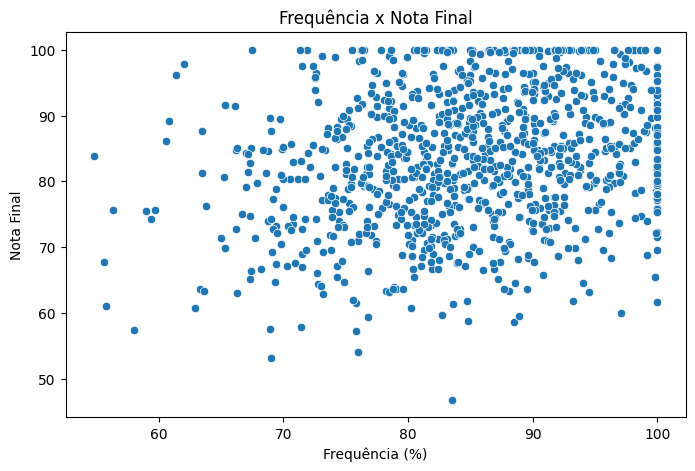

In [74]:
#frequência x nota final
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x = 'attendance_percent', y = 'final_exam_score')
plt.title('Frequência x Nota Final')
plt.xlabel('Frequência (%)')
plt.ylabel('Nota Final')
plt.show()

In [ ]:
#leve tendência de subida, mas bem mais fraca e espalhada do que as horas de estudo

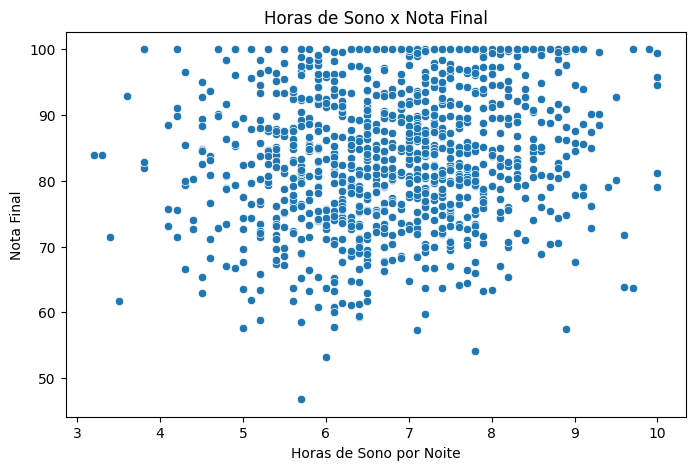

In [77]:
#horas de sono x nota final
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x = 'sleep_hours', y = 'final_exam_score')
plt.title('Horas de Sono x Nota Final')
plt.xlabel('Horas de Sono por Noite')
plt.ylabel('Nota Final')
plt.show()

In [ ]:
#mais fraco dos três, nuvem de pontos espalhada em todas as faixas de sono

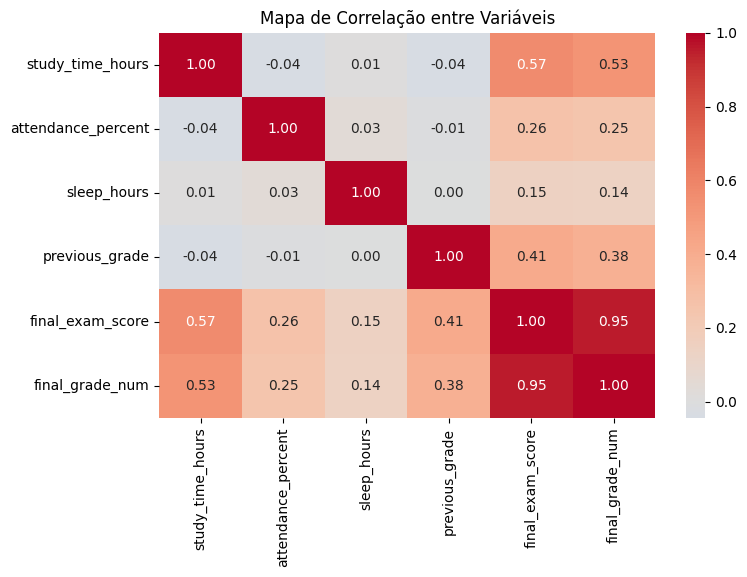

In [79]:
#heatmap dos três fatores:
colunas_numericas = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score', 'final_grade_num']

plt.figure(figsize=(8,5))
correlacao = df[colunas_numericas].corr()
sns.heatmap(correlacao, annot = True, fmt='.2f', cmap='coolwarm', center = 0)
plt.title('Mapa de Correlação entre Variáveis')
plt.show()